In [1]:
import numpy 

import ctypes
import numpy as np
import os
from scipy.interpolate import interp1d

In [36]:
from rapidd.core import _crapidd, base_dir, reset_coefficients, isofromneuc, set_any_Ncoeff, read_halo
from rapidd.experiments import counts_bin_LZ, read_LZ_eff, LZ24_eff_path, efficiency_fn

In [3]:
rhoDM = 0.3 
read_halo()

In [5]:
from rapidd.core import calc_xsec_SI, calc_coeff_SI, difrate_dER

In [7]:
mDM = 50.0 
sigma = 1.0e-45 

reset_coefficients()
set_any_Ncoeff(calc_coeff_SI(mDM, sigma), 1, "p")



In [ ]:
from rapidd.experiments import counts_bin_LZ, lindhard, LZ22_eff_path, LZ24_eff_path, counts_bin_Xe1T, counts_effres_Xe1T, counts_bin_DS50, DS50_LEFF, counts_bin_DS20k, read_DS50_eff, read_DS50_LEFF, read_LZ_eff, read_Xe1T_eff, read_DS20k_eff


In [59]:
energies = np.linspace(0.01, 40, 100)

drde = np.vectorize(difrate_dER)(rhoDM, mDM, energies, basis="ISO")

In [60]:
import matplotlib.pyplot as plt


In [61]:
wrer, wr_drde, wr_drdeeff = np.genfromtxt('../../../others_tool/wimprates/notebooks/wimp_data.txt',
                              unpack=True, skip_header=1)

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
/var/folders/dh/mly6lpj91nbfvtpv36qsw0x00000gn/T/ipykernel_3720/3397178341.py:5: SyntaxWarning: invalid escape sequence '\c'
  plt.title("$m_\chi = 50$ GeV/c${}^2$, $\sigma_\chi = 10^{-45}$ cm${}^2$")


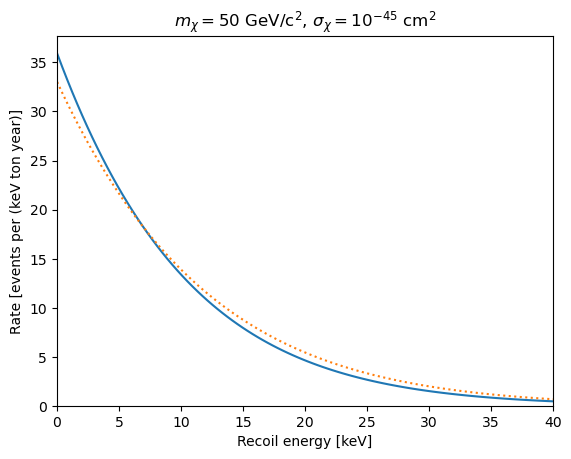

In [62]:
plt.plot(energies, 365250*drde)
plt.plot(wrer, wr_drde, ls=':')
plt.xlabel("Recoil energy [keV]")
plt.ylabel("Rate [events per (keV ton year)]")
plt.title("$m_\chi = 50$ GeV/c${}^2$, $\sigma_\chi = 10^{-45}$ cm${}^2$")
plt.xlim(0, energies.max())
plt.ylim(0, None);

In [63]:
difrate_dER(rhoDM, mDM, 1.0, basis="ISO")*365250

32.6780877786062

In [64]:
read_LZ_eff(LZ24_eff_path)

In [65]:
counts_bin_LZ(rhoDM, mDM, 0.0, 40.0) * (1/(5.6*1e3*1e3))* (4.2 * 365250) 

np.float64(771.072158929928)

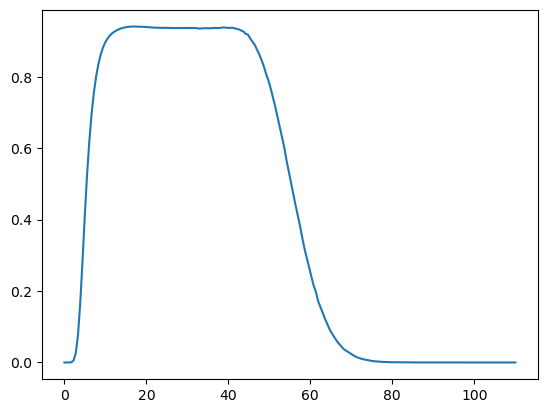

In [66]:
new_en = np.linspace(0, 110, 200)

plt.plot(new_en, np.vectorize(efficiency_fn)(new_en))

In [67]:
def rate_eff(es, mw, rhoDM, sigma):
    reset_coefficients()
    set_any_Ncoeff(calc_coeff_SI(mw, sigma), 1, "p")
    
    dr = difrate_dER(rhoDM, mw, es)
    eff = efficiency_fn(es)
    return dr * eff
    

In [68]:
energies = np.linspace(0.01, 40, 100)

drde = np.vectorize(difrate_dER)(rhoDM, mDM, energies, basis="ISO") * 365250
drde_eff = np.vectorize(rate_eff)(energies, mDM, rhoDM, sigma) * 365250



Text(0.5, 0, 'Recoil energy [keV]')

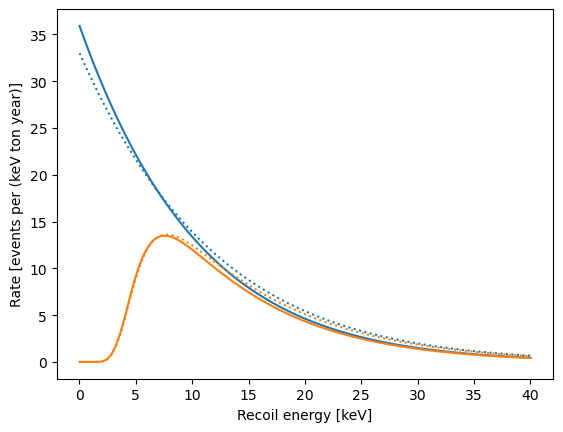

In [70]:
plt.plot(energies, drde, label='Standard rate')
plt.plot(energies, drde_eff, label='Efficiency corrected rate')

plt.plot(wrer, wr_drde, color='tab:blue', ls=":")
plt.plot(wrer, wr_drdeeff, color='tab:orange', ls=':')
plt.ylabel("Rate [events per (keV ton year)]")
plt.xlabel("Recoil energy [keV]")

In [51]:
def calc_LZ24_counts(mw, rhoDM, sigma_nucleon, t=1):
    energies = np.linspace(0.01, 40, 100)
    dr_eff = np.vectorize(rate_eff)(energies, mw, rhoDM, sigma_nucleon) * 365250 * 4.2 # ton year exposure 
    return np.trapezoid(dr_eff, energies) * t

In [52]:
calc_LZ24_counts(50, 0.3, 1e-45)

np.float64(773.6631971271731)

In [71]:
counts_bin_LZ(rhoDM, mDM, 0.0, 40.0) * (1/(5.6*1e3*1e3))* (4.2 * 365250) 

np.float64(771.072158929928)

In [80]:
def calc_LZ24_lim(mw, rhoDM, sigma_ref, t=1):
    counts = calc_LZ24_counts(mw, rhoDM, sigma_ref, t=t)
    return (2.0 / counts) * sigma_ref

In [81]:
LZmdm, LZsig = np.genfromtxt("testoutput/LZ2024_SI.dat", unpack=True)


Text(0, 0.5, 'Cross section [cm${}^2$]')

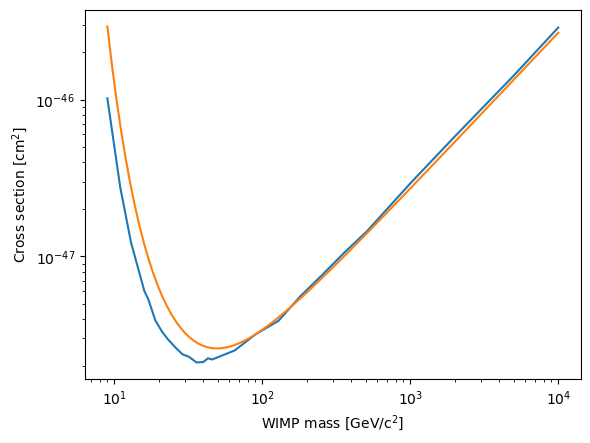

In [82]:
mspace = np.geomspace(min(LZmdm), max(LZmdm), 100) 

plt.plot(LZmdm, LZsig, label='LZ 2024 SI limit')
plt.plot(mspace, [calc_LZ24_lim(m,rhoDM, 1e-45) for m in mspace])
plt.xscale('log')
plt.yscale('log')
plt.xlabel("WIMP mass [GeV/c${}^2$]")
plt.ylabel("Cross section [cm${}^2$]")